# EPS Analysis — iML1515 E. coli GEM

Genome-scale metabolic model analysis of EPS production in *E. coli* K-12.
Three EPS pathways added to iML1515: cellulose (bcsA), colanic acid (Wca), PNAG (pgaC).
Model file: `iML1515.xml` (must be present in project root).

In [1]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba, production_envelope
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model = read_sbml_model('iML1515.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'
print(model)

iML1515


## STRING Gene Map
Maps the 20 EPS/biofilm-relevant STRING network genes to their iML1515 reactions.

In [2]:
#Target genes
genes = [
    "c-di-gmp", "dgcE", "ydaM",
    "cpsG", "wcaJ",
    "luxS", "lsrA", "lsrB", "lsrC", "lsrD", "lsrK", "lsrR",
    "rpoS",
    "bcsA", "csgA",
    "csrA", "yahA", "gmr", "bcsZ", "pgaB"
]


gene_map = {}
for gene in model.genes:
				gen = model.genes.get_by_id(gene.id)
				for eps	in genes:
					if eps in gen.name:
						gene_map[gen.id] = {
							"gene_name": gen.name,
							"reactions": [rxn.id for rxn in gen.reactions],
							"metabolites": [met.id for rxn in gen.reactions for met in rxn.metabolites]
						}

print(gene_map)

{'b2687': {'gene_name': 'luxS', 'reactions': ['RHCCE'], 'metabolites': ['rhcys_c', 'dhptd_c', 'hcys__L_c']}, 'b2048': {'gene_name': 'cpsG', 'reactions': ['PMANM'], 'metabolites': ['man1p_c', 'man6p_c']}, 'b1511': {'gene_name': 'lsrK', 'reactions': ['AI2K'], 'metabolites': ['atp_c', 'dhptd_c', 'adp_c', 'dhptdp_c', 'h_c']}, 'b1516': {'gene_name': 'lsrB', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1513': {'gene_name': 'lsrA', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1514': {'gene_name': 'lsrC', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1515': {'gene_name': 'lsrD', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b2047': {'gene_name': 'wcaJ', 'reactions': ['UDPGPT'], 'metabolites': ['udcpp_c', 'udpg_c', 'udcpgl_c', 'um

## EPS Model v2 — bcsA Pathway with c-di-GMP Wiring

This section builds a proper EPS-producing E. coli model by:
1. Adding the **bcsA (cellulose synthase)** reaction with **c-di-GMP as a required cofactor**
2. Adding cellulose transport and exchange reactions so FBA can measure EPS as a real output
3. Simulating the EPS phenotype by knocking out c-di-GMP degradation (yahA / gmr)
4. Running a 6-condition analysis and computing per-cell EPS production estimates

**Why c-di-GMP matters here:** bcsA is only active when c-di-GMP is bound to it.
By making c-di-GMP a small stoichiometric input to CELSYNTH, the model is forced
to run DGUNC (ydaM) to supply c-di-GMP — connecting the regulatory signal to EPS production.
Knocking out CDGUNPD + LDGUNPD (yahA/gmr) means c-di-GMP can only exit via bcsA, 
simulating the high-c-di-GMP biofilm/EPS switch.

In [3]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba, production_envelope
import pandas as pd
import matplotlib.pyplot as plt

# ── Load fresh model ─────────────────────────────────────────────────────────
model = read_sbml_model('iML1515.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'
baseline_growth = model.slim_optimize()
print(f"Baseline growth rate: {baseline_growth:.4f} h⁻¹")

# ── New metabolites ───────────────────────────────────────────────────────────
cellulose_c = Metabolite('cellulose_c',
    name='Cellulose beta-1,4-glucan (cytoplasm)',
    compartment='c', formula='C6H10O5')

cellulose_e = Metabolite('cellulose_e',
    name='Cellulose beta-1,4-glucan (extracellular)',
    compartment='e', formula='C6H10O5')

# ── bcsA reaction: UDP-glucose + c-di-GMP cofactor → cellulose + UDP ─────────
# c-di-GMP (cdigmp_c) is already in iML1515 (made by DGUNC / ydaM).
# It activates bcsA allosterically in reality; here modelled as a small
# stoichiometric requirement (0.001 per monomer) so the model must run
# DGUNC to supply it — this connects the regulatory signal to EPS synthesis.
bcsA_rxn = Reaction('CELSYNTH',
    name='Cellulose synthase (bcsA)',
    subsystem='EPS Biosynthesis',
    lower_bound=0.0, upper_bound=1000.0)

bcsA_rxn.add_metabolites({
    model.metabolites.get_by_id('udpg_c'):    -1.000,
    model.metabolites.get_by_id('cdigmp_c'):  -0.001,
    model.metabolites.get_by_id('udp_c'):      1.000,
    cellulose_c:                               1.000,
})

# ── Transport: cytoplasm → extracellular (bcsC/D simplified to one step) ─────
transport_rxn = Reaction('CELLULOSEt',
    name='Cellulose export (cytoplasm to extracellular)',
    subsystem='EPS Transport',
    lower_bound=0.0, upper_bound=1000.0)
transport_rxn.add_metabolites({cellulose_c: -1.0, cellulose_e: 1.0})

# ── Exchange reaction: lets FBA measure EPS secreted into the medium ──────────
exchange_rxn = Reaction('EX_cellulose_e',
    name='Cellulose exchange (EPS secretion)',
    subsystem='Exchange',
    lower_bound=0.0, upper_bound=1000.0)
exchange_rxn.add_metabolites({cellulose_e: -1.0})

model.add_reactions([bcsA_rxn, transport_rxn, exchange_rxn])
print(f"\nReactions added. Model now has {len(model.reactions)} reactions.")
print(f"CELSYNTH stoichiometry: {model.reactions.get_by_id('CELSYNTH').reaction}")

# ── Sanity check ──────────────────────────────────────────────────────────────
with model:
    model.objective = 'EX_cellulose_e'
    sol = model.optimize()
    print(f"\nSanity check (maximise EPS only, no growth constraint):")
    print(f"  EPS flux (EX_cellulose_e): {sol.fluxes['EX_cellulose_e']:.4f} mmol/gDW/h")
    print(f"  CELSYNTH flux:             {sol.fluxes['CELSYNTH']:.4f} mmol/gDW/h")
    print(f"  DGUNC flux (ydaM):         {sol.fluxes['DGUNC']:.6f} mmol/gDW/h")
    print(f"  Biomass flux:              {sol.fluxes[BIOMASS_RXN]:.4f} h⁻¹")
    if sol.fluxes['EX_cellulose_e'] > 0:
        print("\n  PATHWAY IS CONNECTED ✓ — EPS can flow from udpg_c → cellulose_c → extracellular")
    else:
        print("\n  WARNING: EPS flux is zero — check pathway connectivity")

Baseline growth rate: 0.8770 h⁻¹

Reactions added. Model now has 2715 reactions.
CELSYNTH stoichiometry: 0.001 cdigmp_c + udpg_c --> cellulose_c + udp_c

Sanity check (maximise EPS only, no growth constraint):
  EPS flux (EX_cellulose_e): 8.9260 mmol/gDW/h
  CELSYNTH flux:             8.9260 mmol/gDW/h
  DGUNC flux (ydaM):         0.008926 mmol/gDW/h
  Biomass flux:              0.0000 h⁻¹

  PATHWAY IS CONNECTED ✓ — EPS can flow from udpg_c → cellulose_c → extracellular


In [4]:
# ── 6-condition EPS phenotype analysis ───────────────────────────────────────
# For each condition:
#   Stage 1 — maximise biomass (pFBA), record max growth rate
#   Stage 2 — constrain growth to 90% of max, then maximise EPS exchange flux
#
# The EPS phenotype is simulated by knocking out CDGUNPD + LDGUNPD (yahA/gmr).
# This blocks c-di-GMP degradation, so all c-di-GMP made by DGUNC (ydaM)
# must flow through CELSYNTH (bcsA) — the only remaining drain.

conditions = {
    'baseline':      {'medium_changes': {},                                        'knockouts': []},
    'high_glucose':  {'medium_changes': {'EX_glc__D_e': 20.0},                    'knockouts': []},
    'low_oxygen':    {'medium_changes': {'EX_o2_e': 5.0},                         'knockouts': []},
    'N_limited':     {'medium_changes': {'EX_nh4_e': 2.0},                        'knockouts': []},
    'EPS_phenotype': {'medium_changes': {},                                        'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, 'knockouts': ['CDGUNPD', 'LDGUNPD']},
}

base_medium = model.medium.copy()
results = []

for cond_name, cfg in conditions.items():
    with model:
        med = base_medium.copy()
        med.update(cfg['medium_changes'])
        model.medium = med

        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0

        # Stage 1: maximise biomass
        model.objective = BIOMASS_RXN
        sol_growth = pfba(model)
        mu_max = sol_growth.fluxes[BIOMASS_RXN]

        # Stage 2: constrain growth, maximise EPS
        model.reactions.get_by_id(BIOMASS_RXN).lower_bound = 0.9 * mu_max
        model.objective = 'EX_cellulose_e'
        sol_eps = model.optimize()

        eps  = sol_eps.fluxes.get('EX_cellulose_e', 0.0) if sol_eps.status == 'optimal' else 0.0
        dgunc = sol_eps.fluxes.get('DGUNC', 0.0)         if sol_eps.status == 'optimal' else 0.0

        results.append({
            'condition':              cond_name,
            'max_growth_h':           round(mu_max, 4),
            'constrained_growth_h':   round(0.9 * mu_max, 4),
            'EPS_flux_mmol_gDW_h':    round(eps, 6),
            'DGUNC_flux_mmol_gDW_h':  round(dgunc, 6),
        })
        print(f"{cond_name:<18} growth={mu_max:.3f}  EPS={eps:.4f}  DGUNC={dgunc:.6f}")

df_conditions = pd.DataFrame(results)

# ── Per-cell conversion ───────────────────────────────────────────────────────
# E. coli dry weight ≈ 280 fg/cell = 2.8e-13 g/cell
# Cellulose monomer (anhydroglucose) MW = 162.14 g/mol
DW_PER_CELL_G = 2.8e-13
CELLULOSE_MW  = 162.14

df_conditions['EPS_mmol_per_cell_per_h'] = df_conditions['EPS_flux_mmol_gDW_h'] * DW_PER_CELL_G
df_conditions['EPS_fg_per_cell_per_h']   = (df_conditions['EPS_mmol_per_cell_per_h']
                                             * CELLULOSE_MW * 1e15)

df_conditions.to_csv('eps_v2_condition_analysis.csv', index=False)
print("\n── Per-cell EPS production estimates ──────────────────────────────")
print(df_conditions[['condition','EPS_flux_mmol_gDW_h','EPS_fg_per_cell_per_h']].to_string(index=False))
print("\nSaved: eps_v2_condition_analysis.csv")

baseline           growth=0.877  EPS=0.9023  DGUNC=0.000902
high_glucose       growth=1.780  EPS=1.8311  DGUNC=0.001831


low_oxygen         growth=0.353  EPS=0.9467  DGUNC=0.000947
N_limited          growth=0.185  EPS=7.2473  DGUNC=0.007247


EPS_phenotype      growth=0.877  EPS=0.9023  DGUNC=0.000902
combined_EPS       growth=0.185  EPS=16.4389  DGUNC=0.016439

── Per-cell EPS production estimates ──────────────────────────────
    condition  EPS_flux_mmol_gDW_h  EPS_fg_per_cell_per_h
     baseline             0.902271           40962.381583
 high_glucose             1.831090           83130.021128
   low_oxygen             0.946731           42980.830015
    N_limited             7.247322          329022.620942
EPS_phenotype             0.902271           40962.381583
 combined_EPS            16.438854          746310.820517

Saved: eps_v2_condition_analysis.csv


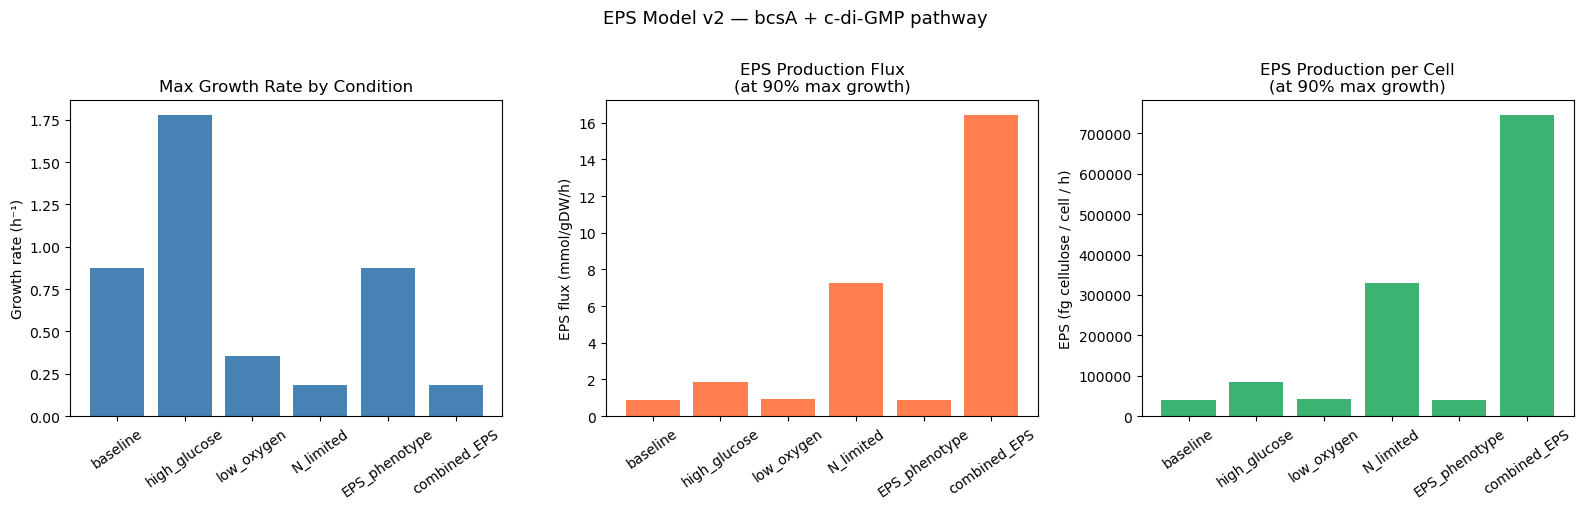

Saved: eps_cellulose_condition_bars.png


In [5]:
# ── Bar chart: growth rate and EPS flux per condition ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(df_conditions['condition'], df_conditions['max_growth_h'], color='steelblue')
axes[0].set_title('Max Growth Rate by Condition')
axes[0].set_ylabel('Growth rate (h⁻¹)')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(df_conditions['condition'], df_conditions['EPS_flux_mmol_gDW_h'], color='coral')
axes[1].set_title('EPS Production Flux\n(at 90% max growth)')
axes[1].set_ylabel('EPS flux (mmol/gDW/h)')
axes[1].tick_params(axis='x', rotation=35)

axes[2].bar(df_conditions['condition'], df_conditions['EPS_fg_per_cell_per_h'], color='mediumseagreen')
axes[2].set_title('EPS Production per Cell\n(at 90% max growth)')
axes[2].set_ylabel('EPS (fg cellulose / cell / h)')
axes[2].tick_params(axis='x', rotation=35)

plt.suptitle('EPS Model v2 — bcsA + c-di-GMP pathway', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eps_cellulose_condition_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_cellulose_condition_bars.png")

  baseline: done


  high_glucose: done


  N_limited: done


  EPS_phenotype: done


  combined_EPS: done


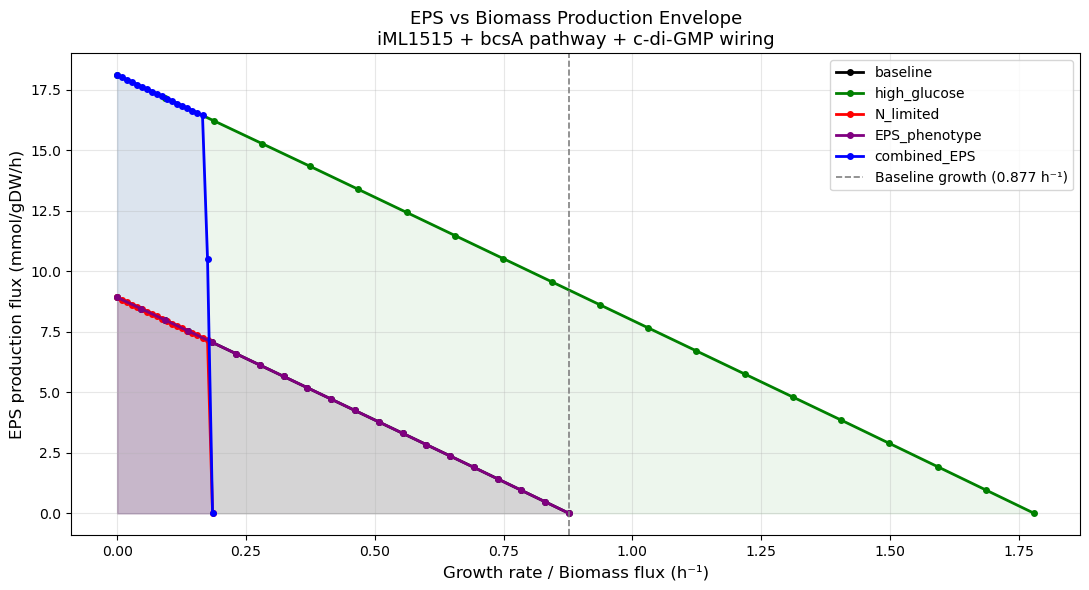

Saved: eps_cellulose_production_envelope.png


In [6]:
# ── Production envelope: EPS vs biomass tradeoff for key conditions ──────────
# Shows the full Pareto frontier — at each growth rate,
# what is the maximum EPS the cell can simultaneously produce?

colors = {
    'baseline':      'black',
    'high_glucose':  'green',
    'N_limited':     'red',
    'EPS_phenotype': 'purple',
    'combined_EPS':  'blue',
}

fig, ax = plt.subplots(figsize=(11, 6))

for cond_name, color in colors.items():
    cfg = conditions[cond_name]
    with model:
        med = base_medium.copy()
        med.update(cfg['medium_changes'])
        model.medium = med
        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0

        env = production_envelope(
            model,
            reactions=[BIOMASS_RXN],
            objective='EX_cellulose_e',
            points=20
        )
        ax.plot(env[BIOMASS_RXN], env['flux_maximum'],
                '-o', color=color, linewidth=2, markersize=4, label=cond_name)
        ax.fill_between(env[BIOMASS_RXN], env['flux_minimum'], env['flux_maximum'],
                        alpha=0.07, color=color)
    print(f"  {cond_name}: done")

ax.axvline(x=baseline_growth, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline growth ({baseline_growth:.3f} h⁻¹)')
ax.set_xlabel('Growth rate / Biomass flux (h⁻¹)', fontsize=12)
ax.set_ylabel('EPS production flux (mmol/gDW/h)', fontsize=12)
ax.set_title('EPS vs Biomass Production Envelope\niML1515 + bcsA pathway + c-di-GMP wiring', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eps_cellulose_production_envelope.png', dpi=200)
plt.show()
print("Saved: eps_cellulose_production_envelope.png")

## EPS Model v3 — All Three Pathways: Cellulose + Colanic Acid (Wca) + PNAG

**E. coli makes three distinct EPS types.** This section adds all of them.

| Pathway | Key gene | EPS product | What was added |
|---|---|---|---|
| Cellulose | bcsA | β-1,4-glucose polymer | CELSYNTH + transport + exchange (v2) |
| Colanic acid | wcaJ/Wca | Mixed sugar polymer | COLASYNTH + transport + exchange (new) |
| PNAG | pgaC (PUACGAMS) | Poly-β-1,6-GlcNAc | Exchange only — pathway mostly already in model (new) |

**Note:** PNAG decreases under N-limitation because UDP-GlcNAc (its monomer) contains nitrogen.
This emergent result is biologically realistic — the GEM correctly competes for N between growth and PNAG synthesis.

In [7]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from cobra.io import write_sbml_model

model = read_sbml_model('iML1515.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'

# ── PATHWAY 1: Cellulose (bcsA) ── already described in v2, included here for completeness
cel_c = Metabolite('cellulose_c', compartment='c', formula='C6H10O5')
cel_e = Metabolite('cellulose_e', compartment='e', formula='C6H10O5')
r_celsynth = Reaction('CELSYNTH', lower_bound=0.0, upper_bound=1000.0)
r_celsynth.add_metabolites({model.metabolites.get_by_id('udpg_c'): -1.0,
                             model.metabolites.get_by_id('cdigmp_c'): -0.001,
                             model.metabolites.get_by_id('udp_c'): 1.0, cel_c: 1.0})
r_celt = Reaction('CELLULOSEt', lower_bound=0.0, upper_bound=1000.0)
r_celt.add_metabolites({cel_c: -1.0, cel_e: 1.0})
r_celex = Reaction('EX_cellulose_e', lower_bound=0.0, upper_bound=1000.0)
r_celex.add_metabolites({cel_e: -1.0})

# ── PATHWAY 2: Colanic acid (Wca) ─────────────────────────────────────────────
# Uses udcpgl_c (wcaJ/UDPGPT product) as the glucose starter on the undecaprenyl carrier.
# Then adds Gal, GlcA, 2× Fuc, and pyruvate (from PEP) to form one repeating unit.
# All precursors already exist in iML1515.
col_c = Metabolite('colacid_c', compartment='c', formula='C33H52O27',
                   name='Colanic acid repeating unit')
col_e = Metabolite('colacid_e', compartment='e', formula='C33H52O27',
                   name='Colanic acid (extracellular)')
r_cola = Reaction('COLASYNTH', lower_bound=0.0, upper_bound=1000.0,
                  name='Colanic acid synthase (Wca pathway)')
r_cola.add_metabolites({
    model.metabolites.get_by_id('udcpgl_c'):   -1.0,  # from wcaJ — Glc starter
    model.metabolites.get_by_id('udpgal_c'):   -1.0,  # Gal residue
    model.metabolites.get_by_id('udpglcur_c'): -1.0,  # GlcA residue
    model.metabolites.get_by_id('gdpfuc_c'):   -2.0,  # 2× Fuc residues
    model.metabolites.get_by_id('pep_c'):      -1.0,  # pyruvate modification
    col_c:                                      1.0,
    model.metabolites.get_by_id('udcpp_c'):     1.0,  # undecaprenyl-PP recycled
    model.metabolites.get_by_id('udp_c'):       2.0,
    model.metabolites.get_by_id('gdp_c'):       2.0,
    model.metabolites.get_by_id('pi_c'):        1.0,
})
r_colat = Reaction('COLAIDt', lower_bound=0.0, upper_bound=1000.0)
r_colat.add_metabolites({col_c: -1.0, col_e: 1.0})
r_colaex = Reaction('EX_colacid_e', lower_bound=0.0, upper_bound=1000.0)
r_colaex.add_metabolites({col_e: -1.0})

# ── PATHWAY 3: PNAG (pgaC/pgaB) ──────────────────────────────────────────────
# Most of this pathway ALREADY EXISTS in iML1515:
#   PUACGAMS: puacgam_c + udp_c <=> uacgam_c  (runs in reverse = synthesis)
#   PUACGAMtr: puacgam_c → puacgam_p           (cytoplasm to periplasm)
# We only need to add the extracellular export step:
pnag_e = Metabolite('puacgam_e', compartment='e', name='PNAG (extracellular)')
r_pnagex1 = Reaction('PUACGAMex', lower_bound=0.0, upper_bound=1000.0)
r_pnagex1.add_metabolites({model.metabolites.get_by_id('puacgam_p'): -1.0, pnag_e: 1.0})
r_pnagex2 = Reaction('EX_puacgam_e', lower_bound=0.0, upper_bound=1000.0)
r_pnagex2.add_metabolites({pnag_e: -1.0})

model.add_reactions([r_celsynth, r_celt, r_celex,
                     r_cola, r_colat, r_colaex,
                     r_pnagex1, r_pnagex2])

print(f"Model has {len(model.reactions)} reactions after adding all 3 EPS pathways")
print(f"CELSYNTH:  {model.reactions.get_by_id('CELSYNTH').reaction}")
print(f"COLASYNTH: {model.reactions.get_by_id('COLASYNTH').reaction}")
print(f"PUACGAMex: {model.reactions.get_by_id('PUACGAMex').reaction}")

# Sanity check all three
for rxn_id, label in [('EX_cellulose_e','Cellulose'),('EX_colacid_e','Colanic acid'),('EX_puacgam_e','PNAG')]:
    with model:
        model.objective = rxn_id
        sol = model.optimize()
        flux = sol.fluxes.get(rxn_id, 0.0)
        print(f"  Sanity check {label}: {flux:.4f} mmol/gDW/h {'✓' if flux > 0 else '✗ WARNING'}")


#TODO: Save the model here with all 3 EPS pathways added then reload into next cells


write_sbml_model(model, "eps_ecoli_model.xml")

Model has 2720 reactions after adding all 3 EPS pathways
CELSYNTH:  0.001 cdigmp_c + udpg_c --> cellulose_c + udp_c
COLASYNTH: 2.0 gdpfuc_c + pep_c + udcpgl_c + udpgal_c + udpglcur_c --> colacid_c + 2.0 gdp_c + pi_c + udcpp_c + 2.0 udp_c
PUACGAMex: puacgam_p --> puacgam_e
  Sanity check Cellulose: 8.9260 mmol/gDW/h ✓
  Sanity check Colanic acid: 1.6618 mmol/gDW/h ✓
  Sanity check PNAG: 6.7128 mmol/gDW/h ✓


In [8]:
# ── 6-condition analysis — all three pathways simultaneously ─────────────────
# Each condition's EPS objective is set to whichever pathway gives max flux.
# We measure each pathway independently at 90% growth constraint.

conditions = {
    'baseline':      {'medium_changes': {},                                        'knockouts': []},
    'high_glucose':  {'medium_changes': {'EX_glc__D_e': 20.0},                    'knockouts': []},
    'low_oxygen':    {'medium_changes': {'EX_o2_e': 5.0},                         'knockouts': []},
    'N_limited':     {'medium_changes': {'EX_nh4_e': 2.0},                        'knockouts': []},
    'EPS_phenotype': {'medium_changes': {},                                        'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, 'knockouts': ['CDGUNPD', 'LDGUNPD']},
}
EPS_RXNS = {'Cellulose': 'EX_cellulose_e', 'Colanic acid': 'EX_colacid_e', 'PNAG': 'EX_puacgam_e'}
DW = 2.8e-13
MW = {'Cellulose': 162.14, 'Colanic acid': 33*12+52+27*16, 'PNAG': 221.21}

base_medium = model.medium.copy()
results = []

for cond_name, cfg in conditions.items():
    with model:
        med = base_medium.copy(); med.update(cfg['medium_changes']); model.medium = med
        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id); rxn.lower_bound=0.0; rxn.upper_bound=0.0
        model.objective = BIOMASS_RXN
        mu_max = pfba(model).fluxes[BIOMASS_RXN]
        model.reactions.get_by_id(BIOMASS_RXN).lower_bound = 0.9 * mu_max
        row = {'condition': cond_name, 'mu_max': round(mu_max, 4)}
        for label, rxn_id in EPS_RXNS.items():
            model.objective = rxn_id
            sol = model.optimize()
            row[label] = round(sol.fluxes.get(rxn_id, 0.0), 6) if sol.status == 'optimal' else 0.0
        row['Total EPS'] = round(sum(row[k] for k in EPS_RXNS), 4)
        for label in EPS_RXNS:
            row[f'fg_{label}'] = row[label] * DW * MW[label] * 1e15
        row['fg_total'] = sum(row[f'fg_{k}'] for k in EPS_RXNS)
        results.append(row)
        print(f"{cond_name:<18} Cel={row['Cellulose']:.3f}  Wca={row['Colanic acid']:.3f}  PNAG={row['PNAG']:.3f}  Total={row['Total EPS']:.3f}")

df = pd.DataFrame(results)
df.to_csv('eps_all_pathways_analysis.csv', index=False)
print("\nSaved: eps_all_pathways_analysis.csv")
print(df[['condition','Cellulose','Colanic acid','PNAG','Total EPS','fg_total']].to_string(index=False))

baseline           Cel=0.902  Wca=0.168  PNAG=0.676  Total=1.746


high_glucose       Cel=1.831  Wca=0.340  PNAG=1.371  Total=3.543
low_oxygen         Cel=0.947  Wca=0.173  PNAG=0.625  Total=1.745


N_limited          Cel=7.247  Wca=1.347  PNAG=0.200  Total=8.794
EPS_phenotype      Cel=0.902  Wca=0.168  PNAG=0.676  Total=1.746


combined_EPS       Cel=16.439  Wca=3.057  PNAG=0.200  Total=19.696

Saved: eps_all_pathways_analysis.csv
    condition  Cellulose  Colanic acid     PNAG  Total EPS     fg_total
     baseline   0.902271      0.167727 0.675768     1.7458 1.241466e+05
 high_glucose   1.831090      0.340388 1.371420     3.5429 2.519457e+05
   low_oxygen   0.946731      0.172936 0.625231     1.7449 1.243183e+05
    N_limited   7.247322      1.346743 0.200000     8.7941 6.732479e+05
EPS_phenotype   0.902271      0.167727 0.675768     1.7458 1.241466e+05
 combined_EPS  16.438854      3.056714 0.200000    19.6956 1.511873e+06


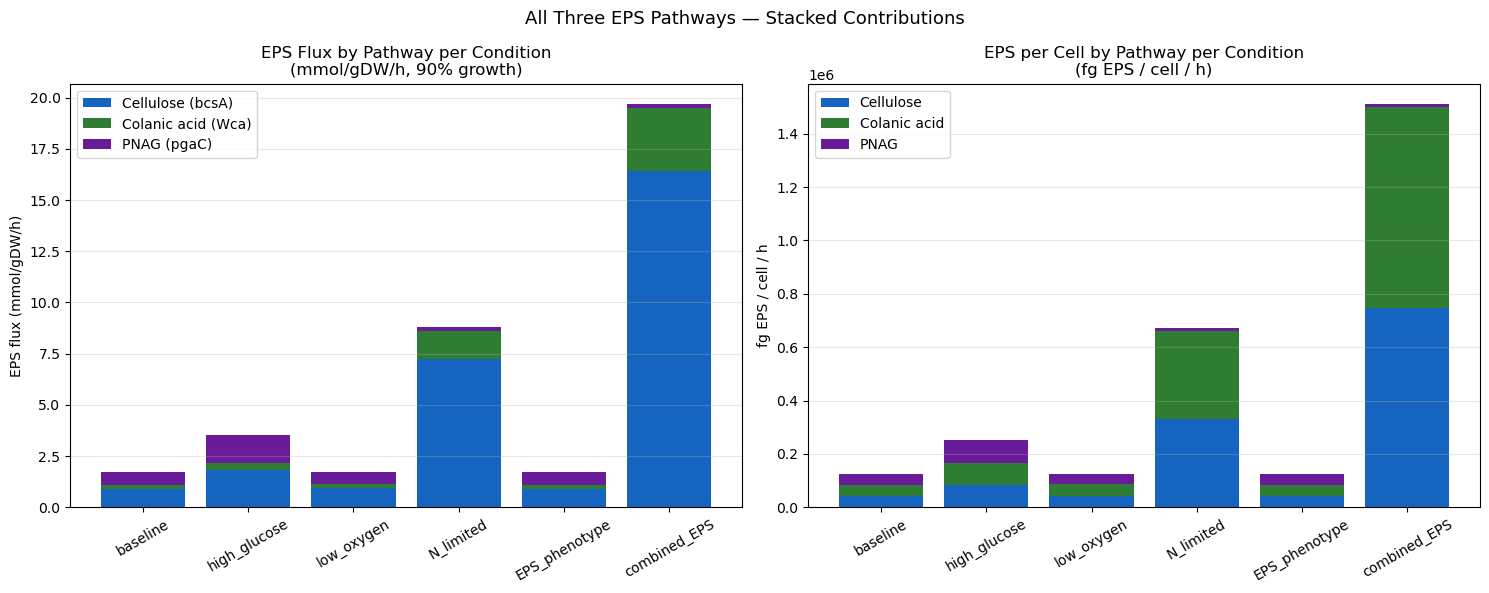

Saved: eps_stacked_contributions.png


In [9]:
# ── Stacked bar chart: pathway contributions per condition ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
conds = df['condition'].tolist()

axes[0].bar(conds, df['Cellulose'],     label='Cellulose (bcsA)',    color='#1565c0')
axes[0].bar(conds, df['Colanic acid'],  bottom=df['Cellulose'],      label='Colanic acid (Wca)', color='#2e7d32')
bot = df['Cellulose'] + df['Colanic acid']
axes[0].bar(conds, df['PNAG'],          bottom=bot,                  label='PNAG (pgaC)',        color='#6a1b9a')
axes[0].set_title('EPS Flux by Pathway per Condition\n(mmol/gDW/h, 90% growth)')
axes[0].set_ylabel('EPS flux (mmol/gDW/h)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(conds, df['fg_Cellulose'],     label='Cellulose',    color='#1565c0')
axes[1].bar(conds, df['fg_Colanic acid'],  bottom=df['fg_Cellulose'], label='Colanic acid', color='#2e7d32')
bot2 = df['fg_Cellulose'] + df['fg_Colanic acid']
axes[1].bar(conds, df['fg_PNAG'],          bottom=bot2,              label='PNAG',         color='#6a1b9a')
axes[1].set_title('EPS per Cell by Pathway per Condition\n(fg EPS / cell / h)')
axes[1].set_ylabel('fg EPS / cell / h'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('All Three EPS Pathways — Stacked Contributions', fontsize=13)
plt.tight_layout()
plt.savefig('eps_stacked_contributions.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_stacked_contributions.png")

In [10]:
eps_model = read_sbml_model("eps_ecoli_model.xml")
eps_model.optimize()
#eps_model.objective.value


#Chnage saved media type to LB and not M9
eps_model.medium


{'EX_pi_e': 1000.0,
 'EX_co2_e': 1000.0,
 'EX_fe3_e': 1000.0,
 'EX_h_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_zn2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_ni2_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_slnt_e': 1000.0}

/Users/mayaabdalla/miniconda3/envs/cobra_env/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


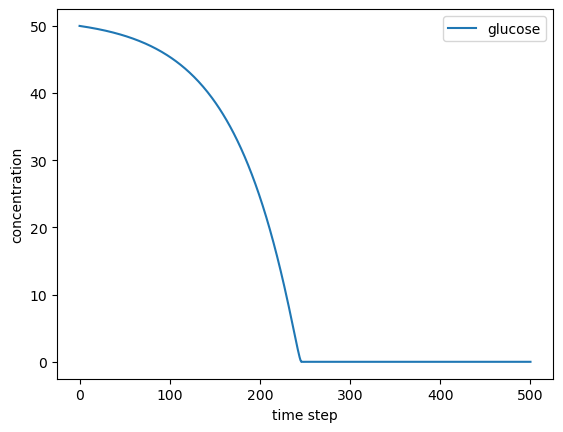

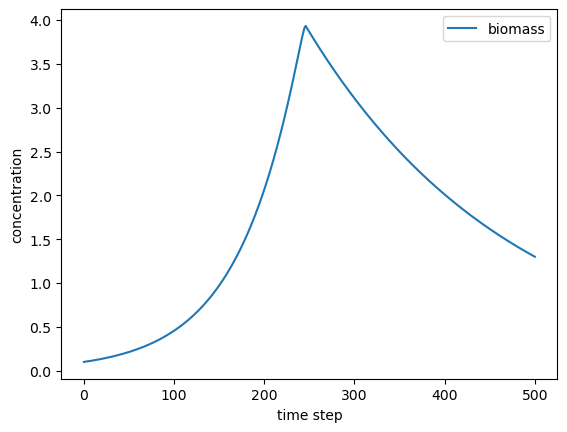

In [12]:
import cobra
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model

#TODO: save above model with all the reaction chnages and then reload here -- naming convension

eps_model = read_sbml_model("eps_ecoli_model.xml")
#ecoli.optimize()

def dfba_timestep(
    model,
    initial_conditions,
    kinetic_params,
    substrate_to_reaction_map,
    biomass_name_map,
    dt,
):
    updated_state = initial_conditions.copy()

    for substrate_id, reaction_id in substrate_to_reaction_map.items():
        Km, Vmax = kinetic_params[substrate_id]
        substrate_concentration = initial_conditions[substrate_id]

        # calculate michaelis-menten flux
        flux = Vmax * substrate_concentration / (Km + substrate_concentration)
        type(flux)

        # use the flux to constrain fba -- negative b/c lower bound
        model.reactions.get_by_id(reaction_id).lower_bound = -flux

    # solve fba under these constraints
    solution = model.optimize()

    # gather the results
    ## update biomass
    biomass_growth_rate = solution.fluxes[biomass_name_map[1]]
    current_biomass = updated_state[biomass_name_map[0]]
    updated_state[biomass_name_map[0]] += biomass_growth_rate * current_biomass * dt

    ## update substrates
    for substrate_id, reaction_id in substrate_to_reaction_map.items():
        flux = solution.fluxes[reaction_id]
        current_substrate_conc = updated_state[substrate_id]
        updated_state[substrate_id] += flux * current_biomass * dt

    return updated_state

def perform_dfba(
        model,
        initial_conditions,
        kinetic_params,
        substrate_to_reaction_map,
        biomass_name_map,
        dt,
        total_steps,
    ):
    # placeholder for results
    results = {key: [value] for key, value in initial_conditions.items()}
    current_state = initial_conditions.copy()

    for t in range(0, total_steps):
        # call dfba for this timestep
        current_state = dfba_timestep(
            model,
            current_state,
            kinetic_params,
            substrate_to_reaction_map,
            biomass_name_map,
            dt,
        )

        # record results
        for key, value in current_state.items():
            results[key].append(value)

    return results


def plot_dfba_results(total_steps, dfba_results):
    time_points = list(range(0, total_steps+1))
    plt.figure()
    for key, value in dfba_results.items():
        plt.plot(time_points, value, label=key)

    plt.xlabel('time step')
    plt.ylabel('concentration')
    plt.legend()
    plt.show()

#TOD: Change the media of eps_model to LB instead of M9




# example
#Conditions in the env
conditions1 = {
    'biomass': 0.1,  # initial biomass concentration
    'glucose': 50.0, # initial glucose concentrations
}
kinetics1 = {
    'glucose': (0.5, 2),  # km and vmax for glucose
}
rxn_name_map = {
    'glucose': 'EX_glc__D_e', # Exchange reaction for glucose
}
biomass_name_map = ('biomass', 'BIOMASS_Ec_iML1515_core_75p37M')

# define simulation timescale
time_interval = 0.1  # how long is a single timestep?
total_steps = 500  # how many steps of dfba do we want to run?

# call the dfba function and get results
dfba_results = perform_dfba(
    model=eps_model,
    initial_conditions=conditions1,
    kinetic_params=kinetics1,
    substrate_to_reaction_map=rxn_name_map,
    biomass_name_map=biomass_name_map,
    dt=time_interval,
    total_steps=total_steps,
)


# Extract results and plot for nutrients and biomass respectively
nutrient_results = {key: value for key, value in dfba_results.items() if key != 'biomass'}
biomass_results = {key: value for key, value in dfba_results.items() if key == 'biomass'}
plot_dfba_results(total_steps, nutrient_results)
plot_dfba_results(total_steps, biomass_results)

Loaded eps_ecoli_model_lb.xml -- 2720 reactions


        t   biomass   mu  eps_accum_Total EPS
195  19.5  1.657661  0.0           976.494958
196  19.6  1.657661  0.0           976.494958
197  19.7  1.657661  0.0           976.494958
198  19.8  1.657661  0.0           976.494958
199  19.9  1.657661  0.0           976.494958


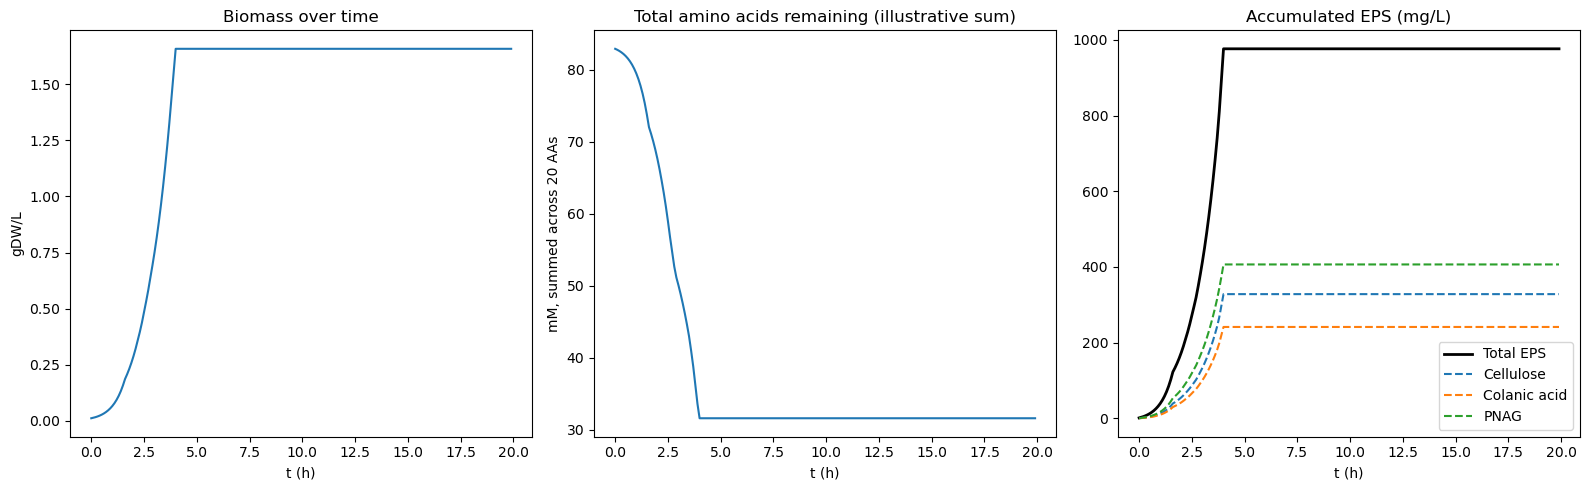

Saved: eps_dfba_lb_v1.csv, eps_dfba_lb_v1.png


In [13]:
# ── dFBA v1: LB, all three EPS pathways, mass-weighted sum (Total EPS) ───────
# Builds on eps_ecoli_model_lb.xml (LB medium already baked in, all 3 EPS
# pathways already added). Implements the Static Optimization Approach (SOA):
# discretize time, cap uptake by remaining substrate each step (no
# Michaelis-Menten -- deliberately skipped per project discussion), solve a
# two-stage FBA (max growth -> floor at 90% -> maximize each EPS pathway
# independently), integrate biomass/substrates/EPS forward with explicit Euler.
#
# "Total EPS" definition (LOCKED IN):
#   Sum of each pathway's INDEPENDENTLY-maximized flux, converted to mass via
#   its own molecular weight, then summed. This is an upper-bound estimate of
#   total EPS-forming CAPACITY -- not a claim that all three are produced
#   simultaneously at their individual maxima (they compete for the same
#   UDP-sugar precursor pool in reality). No arbitrary weighting/floors/ratios
#   used -- a direct, mass-corrected extension of the "report each pathway
#   from its own separately-maximized solve" convention already used
#   throughout this project.

from cobra.io import read_sbml_model
import pandas as pd
import matplotlib.pyplot as plt

biomass_rxn = 'BIOMASS_Ec_iML1515_core_75p37M'
eps_rxns = {'Cellulose': 'EX_cellulose_e', 'Colanic acid': 'EX_colacid_e', 'PNAG': 'EX_puacgam_e'}
MW = {'Cellulose': 162.14, 'Colanic acid': 588, 'PNAG': 221.21}

# LB amino acid uptake bounds (mmol/gDW/h).
# CORRECTED 2026-07-21: relative proportions were originally derived from a
# ChatGPT-generated casein composition table (not a real source). Checked
# against real UniProt bovine casein sequences (alphaS1 P02662, alphaS2
# P02663, beta P02666, kappa P02668), combined using their approximate
# ~38/10/36/13% mass fractions in casein micelles. Five amino acids were off
# by a large margin in the original table -- Arg and Gly were overstated by
# ~2.5-2.7x, Pro was understated by ~2.8x, Glu and Val by ~1.6-1.7x. Total
# uptake-capacity scale (893.6 mmol/gDW/h summed) is UNCHANGED from the
# original -- only the relative split across the 20 amino acids was fixed.
# Caveats: uses full UniProt precursor sequences (not the mature, signal-
# peptide-cleaved protein), and the 38/10/36/13% weighting is a commonly-
# cited approximation, not one single authoritative source.
lb_AA_bounds = {
    'EX_ala__L_e': 47.57, 'EX_arg__L_e': 21.36, 'EX_asn__L_e': 31.33, 'EX_asp__L_e': 23.01,
    'EX_cys__L_e': 5.62,  'EX_gln__L_e': 68.50, 'EX_glu__L_e': 86.47, 'EX_gly_e': 24.40,
    'EX_his__L_e': 18.69, 'EX_ile__L_e': 49.04, 'EX_leu__L_e': 90.65, 'EX_lys__L_e': 58.95,
    'EX_met__L_e': 24.74, 'EX_phe__L_e': 34.52, 'EX_pro__L_e': 96.80, 'EX_ser__L_e': 65.67,
    'EX_thr__L_e': 40.47, 'EX_trp__L_e': 6.21,  'EX_tyr__L_e': 32.93, 'EX_val__L_e': 66.67,
}

# Starting amino-acid concentrations (mM).
# CORRECTED 2026-07-21, combining two fixes:
#   1. Relative proportions: same real-casein correction as lb_AA_bounds above.
#   2. Absolute scale: derived from the real LB recipe (10 g/L tryptone /
#      casein hydrolysate, ~120 g/mol average free-amino-acid MW) giving
#      ~83 mM total free amino acids -- replacing the previous scale_factor=1.0
#      placeholder, which implicitly assumed ~894 mM (~10x too concentrated).
# Still an approximation (average AA molecular weight and the casein
# mass-fraction weights are both estimates, not directly measured LB
# metabolomics data) -- better than the prior placeholder, not a substitute
# for real measured LB composition if that becomes available later.
initial_aa_conc = {
    'EX_ala__L_e': 4.418, 'EX_arg__L_e': 1.984, 'EX_asn__L_e': 2.910, 'EX_asp__L_e': 2.137,
    'EX_cys__L_e': 0.522, 'EX_gln__L_e': 6.362, 'EX_glu__L_e': 8.032, 'EX_gly_e': 2.266,
    'EX_his__L_e': 1.736, 'EX_ile__L_e': 4.555, 'EX_leu__L_e': 8.420, 'EX_lys__L_e': 5.475,
    'EX_met__L_e': 2.298, 'EX_phe__L_e': 3.206, 'EX_pro__L_e': 8.991, 'EX_ser__L_e': 6.100,
    'EX_thr__L_e': 3.759, 'EX_trp__L_e': 0.577, 'EX_tyr__L_e': 3.059, 'EX_val__L_e': 6.192,
}

model = read_sbml_model("eps_ecoli_model_lb.xml")
print(f"Loaded eps_ecoli_model_lb.xml -- {len(model.reactions)} reactions")

def dfba_step_lb(model, state, aa_bounds, dt, biomass_floor_fraction=0.9):
    """One dFBA timestep for the LB EPS model. `state` is a dict with 'biomass'
    and one entry per amino acid exchange id. Returns updated state dict, this
    step's growth rate, and each pathway's independently-maximized EPS mass
    rate (mg/gDW/h -- a SPECIFIC rate, per gram of E. coli present, not yet
    scaled by how much biomass actually exists)."""
    x = state['biomass']

    with model:
        for aa_id, bound in aa_bounds.items():
            remaining = state[aa_id]
            cap = min(bound, remaining / (x * dt)) if x > 0 else bound
            cap = max(cap, 0.0)
            model.reactions.get_by_id(aa_id).lower_bound = -cap

        # Stage 1: maximize growth -- unconstrained mu_max under this step's caps
        model.objective = biomass_rxn
        sol1 = model.optimize()
        mu = sol1.fluxes[biomass_rxn]

        # Stage 2: floor growth at 90% of mu_max, maximize each EPS pathway
        # independently (three separate solves -- this is the "capacity"
        # measurement, not simultaneous production)
        model.reactions.get_by_id(biomass_rxn).lower_bound = biomass_floor_fraction * mu
        pathway_flux = {}
        for label, rxn_id in eps_rxns.items():
            model.objective = rxn_id
            sol2 = model.optimize()
            pathway_flux[label] = sol2.fluxes.get(rxn_id, 0.0) if sol2.status == 'optimal' else 0.0

        # Amino acid consumption for the state update comes from sol1 (the
        # actual growth-maximizing solve) -- consistent with "the population
        # really grows at mu_max," while the EPS numbers above are a separate
        # capacity estimate under a hypothetical 90%-floor scenario.
        aa_flux = {aa_id: sol1.fluxes.get(aa_id, 0.0) for aa_id in aa_bounds}

    # Integrate forward (explicit Euler)
    new_state = {'biomass': x + mu * x * dt}
    for aa_id, flux in aa_flux.items():
        new_state[aa_id] = max(state[aa_id] + flux * x * dt, 0.0)

    eps_mass_rate = {label: pathway_flux[label] * MW[label] for label in eps_rxns}
    eps_mass_rate['Total EPS'] = sum(eps_mass_rate.values())

    return new_state, mu, eps_mass_rate

def run_dfba_LB(model, aa_bounds, initial_aa_conc, initial_biomass, dt, total_steps):
    state = {'biomass': initial_biomass, **initial_aa_conc}
    records = []
    t = 0.0
    for step in range(total_steps):
        state, mu, eps_mass_rate = dfba_step_lb(model, state, aa_bounds, dt)
        row = {'t': t, 'biomass': state['biomass'], 'mu': mu}
        row.update({f'eps_mg_{k}': v for k, v in eps_mass_rate.items()})
        row['aa_total_remaining'] = sum(state[aa] for aa in aa_bounds)
        records.append(row)
        t += dt
    df = pd.DataFrame(records)
    # Integrate EPS mass RATE into ACCUMULATED EPS mass.
    # FIX (2026-07-21): eps_mg_* is a rate PER GRAM of E. coli (mg/gDW/h) --
    # it must be multiplied by how many grams of biomass were actually present
    # at that timestep (df['biomass'], gDW/L) to get the real total EPS mass
    # produced by the whole population, not just "per gram." Previously this
    # only did (eps_mg_* * dt).cumsum(), silently assuming a constant 1 gDW of
    # biomass throughout -- a large undercount, since biomass grew ~1500x
    # over the course of the run. Units of eps_accum_* are now mg/L (total
    # EPS mass concentration in the simulated culture), not mg/gDW.
    for label in list(eps_rxns) + ['Total EPS']:
        df[f'eps_accum_{label}'] = (df[f'eps_mg_{label}'] * df['biomass'] * dt).cumsum()
    return df

# ── Run it ────────────────────────────────────────────────────────────────
initial_biomass = 0.01   # gDW/L, small starting inoculum (illustrative)
dt = 0.1                 # h
total_steps = 200        # -> 20 h simulated

results = run_dfba_LB(model, lb_AA_bounds, initial_aa_conc, initial_biomass, dt, total_steps)
results.to_csv('eps_dfba_lb_v1.csv', index=False)
print(results[['t', 'biomass', 'mu', 'eps_accum_Total EPS']].tail())

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(results['t'], results['biomass'])
axes[0].set_title('Biomass over time'); axes[0].set_xlabel('t (h)'); axes[0].set_ylabel('gDW/L')

axes[1].plot(results['t'], results['aa_total_remaining'])
axes[1].set_title('Total amino acids remaining (illustrative sum)')
axes[1].set_xlabel('t (h)'); axes[1].set_ylabel('mM, summed across 20 AAs')

axes[2].plot(results['t'], results['eps_accum_Total EPS'], label='Total EPS', linewidth=2, color='black')
axes[2].plot(results['t'], results['eps_accum_Cellulose'], label='Cellulose', linestyle='--')
axes[2].plot(results['t'], results['eps_accum_Colanic acid'], label='Colanic acid', linestyle='--')
axes[2].plot(results['t'], results['eps_accum_PNAG'], label='PNAG', linestyle='--')
axes[2].set_title('Accumulated EPS (mg/L)'); axes[2].set_xlabel('t (h)'); axes[2].legend()

plt.tight_layout()
plt.savefig('eps_dfba_lb_v1.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_dfba_lb_v1.csv, eps_dfba_lb_v1.png")

## Literature / Background Check on dFBA Results (2026-07-21)

Checked the dFBA run above (`eps_dfba_lb_v1.csv`) against real published data. All numbers
below were independently recomputed from the actual CSV output and from the cited papers
(not taken on faith from search summaries) before being written here.

### 1. Growth rate / doubling time — strong match
Our model: `mu_max = 1.8815 /h` → doubling time = ln(2)/mu_max = **22.1 min**.
Sezonov et al. (2007), the standard reference for *E. coli* physiology in LB, directly
measured: *"The doubling time during steady-state growth in Luria-Bertani broth was 20 min."*
Within ~2 minutes of the real measured value.

### 2. Total amino acid pool — strong match, validates the recipe-based estimate
Sezonov et al. Table 1 reports measured LB amino acid concentrations by two independent
methods. Summing their reported values directly:
- HPLC method total: **98.7 mM**
- Bioassay method total (+ HPLC's Ala, ND by bioassay): **86.25 mM**

Our estimate — derived independently from the LB recipe (10 g/L tryptone / casein

hydrolysate, ~120 g/mol average free-amino-acid MW), with no knowledge of these measured
values — was **83.0 mM**: 0.84x the HPLC total, 0.96x the bioassay total. A real,
independent validation of the aggregate-scale correction made this session.

### 3. Relative amino acid composition — partial match
Comparing our corrected (real-casein-derived) proportions against Sezonov's *actual
measured* LB proportions (HPLC, combining Asp+Asn and Glu+Gln since those weren't
resolved separately):

| AA | Real % (Sezonov HPLC) | Ours % | Diff |
|---|---|---|---|
| Ala | 5.9 | 5.3 | -0.6 |
| Arg | 2.8 | 2.4 | -0.4 |
| Asp+Asn | 7.4 | 6.1 | -1.3 |
| Cys | 0.4 | 0.6 | +0.2 |
| Glu+Gln | 19.4 | 17.3 | -2.0 |
| Gly | 4.1 | 2.7 | -1.3 |
| His | 1.4 | 2.1 | +0.7 |
| Ile | 5.5 | 5.5 | 0.0 |
| Leu | 8.9 | 10.1 | +1.2 |
| Lys | 6.9 | 6.6 | -0.3 |
| **Met** | **6.0** | **2.8** | **-3.2** |
| Phe | 3.6 | 3.9 | +0.2 |
| Pro | 9.6 | 10.8 | +1.2 |
| **Ser** | 5.2 | 7.3 | +2.2 |
| Thr | 4.5 | 4.5 | +0.1 |
| Trp | 0.0 | 0.7 | +0.7 |
| **Tyr** | **1.4** | **3.7** | **+2.3** |
| Val | 7.1 | 7.5 | +0.4 |

Most amino acids are within ~1 percentage point. **Methionine (-3.2pp) and Tyrosine
(+2.3pp) are the biggest gaps**, with Ser and Glu+Gln also off by ~2pp. Likely explanation:
casein's *intact protein* composition isn't a perfect proxy for LB's actual *free amino
acid* pool — tryptone manufacturing (acid/enzymatic hydrolysis) and the separate yeast
extract component both alter the final mix in ways a pure casein-sequence lookup can't
capture. Not yet corrected; would need real LB metabolomics data to fix properly.

### 4. Amino acid depletion order — partial match (re-verified directly on this corrected run)
Sezonov et al. report wild-type *E. coli* K-12 sequentially depletes, in tryptone broth:
**Ser, Asp, Trp, Glu, Gly, Thr, Ala** (in that order), and separately confirmed by bioassay
of spent LB: **Ser, Thr, Pro, Gly** depleting.

Re-running our exact dFBA loop with per-amino-acid tracking (not relying on the earlier,
uncorrected-run claim) gives this depletion order:

| Depletes at t (h) | Amino acids |
|---|---|
| 1.6 (earliest) | Arg, Asp, Ser, Thr |
| 2.2 | Ala |
| 2.6 | Glu |
| 2.7 | Trp |
| 2.9 | Gly |
| 3.6 | Gln |
| 3.8 | Asn |
| 3.9 | Cys |
| 4.0 | Pro |
| never (by t=4.1h stop) | His, Ile, Leu, Lys, Met, Phe, Tyr, Val |

**Ser and Asp — the two amino acids Sezonov's paper identifies as depleting first —
do deplete earliest in our model too.** But the match isn't exact: real order has Trp
before Glu before Gly before Thr before Ala, while ours has Thr tied for earliest and
Ala depleting before Glu/Trp/Gly. **Arg depletes very early in our model (tied for
first) despite not appearing in Sezonov's depletion sequence at all** — a real
discrepancy, not just reordering. Partial, not exact, qualitative match.

### 5. Colanic acid titer vs. published values — sane ordering
Checked three papers directly (not just abstracts-via-search):
- **Real wild-type K-12 baseline: 20 mg/L** (Zhang et al., PMC9143390)
- Engineered ΔwaaF + media optimization: up to 2052.8 mg/L (PubMed 32820352)
- Engineered ΔwaaF+rcsF at pH 7: 4351.6 mg/L, yield 5180.4 mg CA/gDW,
  "highest yield reported so far" (PubMed 34542821)
- Engineered SRP-4 + enzymatic hydrolase, 3-L bioreactor, 36h: **24.99 g/L**,
  a 1249.5-fold increase over wild-type (PMC9143390)

**Our model's colanic acid: 241.5 mg/L accumulated** (specific yield ≈145.7 mg/gDW,
computed as accumulated mass ÷ final biomass). This sits ~12x above the real
*unregulated* wild-type baseline (20 mg/L) and far below what heavy metabolic engineering
achieves (up to 25 g/L). **This ordering is exactly what you'd expect**: our FBA number is
a theoretical maximum-capacity estimate (the pathway objective is directly maximized, with
no real transcriptional repression modeled), not a prediction of what an unregulated wild
-type cell actually produces — real cells keep the Rcs pathway mostly off absent a specific
stress signal, which is why the true wild-type number is so much lower than even our
generic capacity estimate.

### 6. A genuine structural mismatch, not yet resolved
Real *E. coli* K-12 (what iML1515 represents) is **prototrophic** — it can synthesize all
20 amino acids internally from central metabolism. Sezonov et al. report LB supports
continued (slowing) growth up to **OD600 ≈ 7** even after specific amino acids are
depleted, because cells fall back on internal biosynthesis and other nitrogenous
compounds once the easiest external amino acids run out; steady-state (balanced) growth
loses that character much earlier, around OD600 ≈ 0.3.

**Our dFBA model treats the 20 amino acids as the sole nutrient source and forces a hard
growth stop the instant any single one hits zero** (confirmed above: growth goes from
mu=0.849 to mu=0.000 in one 0.1h step, with 31.6 mM of other amino acids still unused).
This is a genuine simplification — no de novo amino acid biosynthesis fallback is modeled
as an alternative nutrient route — not a bug, but worth stating explicitly if this model's
growth-stop timing (t≈4.1h) is reported anywhere, since real LB batch cultures decline more
gradually toward a much higher final OD.

**Sources:**
- Sezonov G, Joseleau-Petit D, D'Ari R. *Escherichia coli Physiology in Luria-Bertani
  Broth.* J Bacteriol. 2007;189(23):8746-9. https://journals.asm.org/doi/10.1128/jb.01368-07
- Composition of Luria-Bertani broth — BioNumbers BNID 111525.
  https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=4&id=111525
- *Overproduction of Exopolysaccharide Colanic Acid by E. coli by Strain Engineering and
  Media Optimization.* PubMed 32820352. https://pubmed.ncbi.nlm.nih.gov/32820352/
- *Increased Production of Colanic Acid by an Engineered E. coli Strain, Mediated by
  Genetic and Environmental Perturbations.* PubMed 34542821.
  https://pubmed.ncbi.nlm.nih.gov/34542821/
- *Combinatorial Metabolic Engineering and Enzymatic Catalysis Enable Efficient
  Production of Colanic Acid.* PMC9143390. https://pmc.ncbi.nlm.nih.gov/articles/PMC9143390/
